## Check the two-poing correlation function

In [11]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import lsstypes as types
import matplotlib.gridspec as gridspec
from mockfactory import Catalog

os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

sys.path.insert(0, '../../')
from cat_tools import get_measurement_fn
from fit_tools import read_data_from_fn
from helper import GET_REDSHIFT_SET

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[000701.32]  05-21 04:29  TwoPointEstimator            INFO     Loading /pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock0/mpspk/mpslog_QSO_z0.8-2.1_NGC_DR2_v2.0.npy.


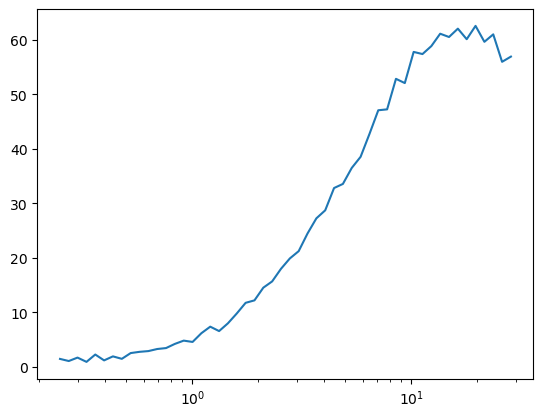

In [28]:
corr = 'mpslog' # xi, pk, mpslog, wplog, mesh2

data_args = dict(
    version = 'AbacusHF-v2',
    tracer = 'QSO',
    region = 'NGC',
    domain = 'altmtl',
    zrange = (0.8, 2.1),
    mockid = 0,
)

fn = get_measurement_fn(**data_args, use_jax=False)
(s,tps),_ = read_data_from_fn(fn, corr)
plt.plot(s, s**2*tps[0], label='mpslog')
plt.xscale('log')

NameError: name 'fn' is not defined

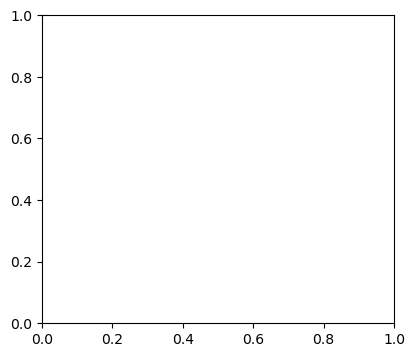

In [3]:
from pycorr import TwoPointCorrelationFunction, project_to_multipoles, project_to_wp

fig = plt.figure(figsize=(10,4))

for ill in [0,1]:
    ax = fig.add_subplot(1,2,ill+1)
    fn1 = '/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/Boxes/QSO/sn1p550/AbacusSummit_base_c000_ph000/mpspk/mpslog_QSO_zp1.550_DR2_v2.0.npy'
    (s, tps), _ = read_data_from_fn(fn, 'mpslog')
    plt.plot(s, s*tps[ill], label = 'AbacusHF sn1p550')

    fn2 = '/global/cfs/cdirs/desi/users/arocher/Y3/loa-v1/v1.1/PIP/cosmo_0/smu/allcounts_QSO_GCcomb_0.8_2.1_pip_angular_bitwise_log_njack128_nran4_split20.npy'
    result = TwoPointCorrelationFunction.load(fn2)
    result = project_to_multipoles(result, ells=(0,2))
    s = result[0]
    xi = result[1]
    plt.plot(s, s*xi[ill], label = 'loa-v1 0.8-2.1')

    fn3 = '/global/cfs/cdirs/desi/users/arocher/Y3/loa-v1/v1.1/PIP/cosmo_0/smu/allcounts_QSO_GCcomb_1.4_1.7_pip_angular_bitwise_log_njack128_nran4_split20.npy'
    result = TwoPointCorrelationFunction.load(fn3)
    result = project_to_multipoles(result, ells=(0,2))
    s = result[0]
    xi= result[1]
    plt.plot(s, s*xi[ill], label = 'loa-v1 1.4-1.7')
    plt.xscale('log')
    if ill == 0:
        plt.legend(fontsize=12)
    plt.ylabel(rf'$s \xi_{ill*2}(s)$', fontsize=12)
    plt.xlabel(r'$s$ [$h^{-1}$Mpc]', fontsize=12)

[006266.45]  06-12 06:30  TwoPointEstimator            INFO     Loading /global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock20/mpspk/wplog_QSO_z0.8-2.1_hf_v2.0_base.npy.


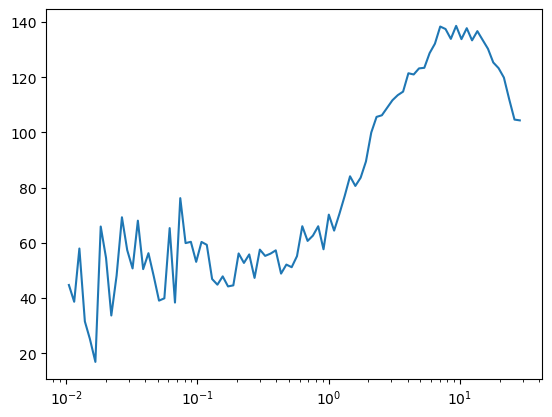

In [ ]:
# fn = '/global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock20/mpspk/wplog_QSO_z0.8-2.1_hf_v2.0_base.npy'
fn = '/global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/LRG/mock12/mpspk/wplog_QSO_z0.8-2.1_hf_v2.0_base.npy'

(r, wp), _ = read_data_from_fn(fn, 'wplog')

plt.plot(r, r*wp, label='AbacusHF-v2 cutsky base')
plt.xscale('log')

In [ ]:
fn = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_clustering.dat.fits' 
Catalog.read(fn)

[004855.66]  06-12 06:06  FileStack                    INFO     Reading /global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_clustering.dat.fits.


Catalog(csize=7875016, size=7875016, columns=['TARGETID', 'TILEID', 'Z', 'NTILE', 'RA', 'DEC', 'PHOTSYS', 'FRAC_TLOBS_TILES', 'WEIGHT_ZFAIL', 'BITWEIGHTS', 'PROB_OBS', 'WEIGHT', 'WEIGHT_COMP', 'WEIGHT_SYS', 'flux_g_dered', 'flux_r_dered', 'flux_z_dered', 'flux_w1_dered', 'flux_w2_dered'])